In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys

sys.path.append('/home/hgf_hmgu/hgf_gib4562/tdmpc2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils import reconstruct_cartpole_dmcontrol
from datetime import datetime
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from tqdm import tqdm


In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from projected_tdmpc2 import ProjectedTDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed
# from common.trajectory_controller import TrajectoryController
# from common.activation_patcher import ActivationPatcher

#from analysis.utils import load_sweep_metadata, load_data

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



## Utils

In [5]:
@torch.no_grad()
def run_dynamics_model(agent, initial_obs, action_sequence, n_steps=100):
    """
    Run dynamics model starting from an initial observation.
    
    Args:
        agent: The TDMPC2 agent
        initial_obs: The initial observation (same one used for z_true to ensure consistency)
        n_steps: Number of steps to run
    """
    obs = initial_obs
    if isinstance(obs, np.ndarray):
        obs = torch.from_numpy(obs)
    if obs.ndim == 3:
        obs = obs.unsqueeze(0)

    z = agent.model.encode(obs.to(agent.device), task=None).squeeze(0)
    z_list = [z.cpu().numpy()]

    for t in range(n_steps - 1):
        #NOTE: I think action_sequence[t] is correct, because in e.g. collect_data() first I act and then I collect an observation
        # but we need to double check this.
        z = agent.model.next(z,
                             torch.tensor(action_sequence[t]).to(agent.device),
                             task=None)
        z_list.append(z.cpu().numpy())

    return np.array(z_list)


In [6]:
CKPT_TO_USE = 500_000

## Initialize environment and agent

In [19]:
def initialize_agent_rgb(projector_rgb):
    """Initialize RGB-based agent with projector."""
    CKPT_TO_USE = 500_000
    CKPT_PATH_RGB = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt'

    override_cfg_rgb = dict(
        task='cartpole-swingup',
        checkpoint=CKPT_PATH_RGB,
        obs='rgb',
        seed=0,
        compile=False,
        mpc=True,
        multitask=False,
        model_size=5,
        save_video=False,
        record_planning=False,
    )

    # Create RGB-based environment
    with initialize(config_path="tdmpc2", version_base=None):
        cfg_rgb = compose(config_name="config")
        OmegaConf.set_struct(cfg_rgb, False)
        cfg_rgb = OmegaConf.merge(cfg_rgb, override_cfg_rgb)

    cfg_rgb = parse_cfg(cfg_rgb)
    set_seed(cfg_rgb.seed)

    cfg_rgb.initial_state = {
        'qpos': {
            'slider': 0,
            'hinge_1': 0,
        },
    }

    env_rgb = make_env(cfg_rgb)

    print("\nLoading RGB-based agent...")
    agent_rgb = ProjectedTDMPC2(cfg_rgb, projector=projector_rgb)
    if hasattr(cfg_rgb, 'checkpoint') and cfg_rgb.checkpoint:
        print(f"Loading checkpoint: {cfg_rgb.checkpoint}")
        agent_rgb.load(cfg_rgb.checkpoint)

    return agent_rgb


def initialize_agent_state(projector_state):
    """Initialize state-based agent with projector."""
    CKPT_TO_USE = 500_000
    CKPT_PATH_STATE = f'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/{CKPT_TO_USE}.pt'

    override_cfg_state = dict(
        task='cartpole-swingup',
        checkpoint=CKPT_PATH_STATE,
        obs='state',
        seed=0,
        compile=False,
        mpc=True,
        multitask=False,
        model_size=5,
        save_video=False,
        record_planning=False,
    )

    # Create state-based environment
    with initialize(config_path="tdmpc2", version_base=None):
        cfg_state = compose(config_name="config")
        OmegaConf.set_struct(cfg_state, False)
        cfg_state = OmegaConf.merge(cfg_state, override_cfg_state)

    cfg_state = parse_cfg(cfg_state)
    set_seed(cfg_state.seed)

    cfg_state.initial_state = {
        'qpos': {
            'slider': 0,
            'hinge_1': 0,
        },
    }

    env_state = make_env(cfg_state)

    print("\nLoading state-based agent...")

    agent_state = ProjectedTDMPC2(cfg_state, projector=projector_state)
    if hasattr(cfg_state, 'checkpoint') and cfg_state.checkpoint:
        print(f"Loading checkpoint: {cfg_state.checkpoint}")
        agent_state.load(cfg_state.checkpoint)

    return agent_state

In [53]:
from common.latent_projector import LatentProjector
from common.nonlinear_latent_projector import NonlinearLatentProjector

path = "/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/pixelv2_pca_projector_k10.pt"

projector_pcas_pixel = {}
for k in [10, 30, 50, 75, 100, 150]:
    path_pixel = f"/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/pixelv2_pca_projector_k{k}.pt"
    projector_pcas_pixel[(k, 'pixel')] = LatentProjector.load(path_pixel)

projector_pcas_state = {}
for k in [8, 9, 10, 11, 12, 13, 14, 15]:
    path_state = f"/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/pca_projector_k{k}.pt"
    projector_pcas_state[(k, 'state')] = LatentProjector.load(path_state)

projector_nonlinears_pixel = {}
for k in [2, 5, 10, 30, 40, 75, 100, 150]:
    path = f"/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/pixelv2_nonlinear_projector_k{k}.pt"
    projector_nonlinears_pixel[(k,
                                'pixel')] = NonlinearLatentProjector.load(path)

projector_nonlinears_state = {}
for k in [1, 2, 3, 4, 5, 5, 7]:
    path = f"/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/nonlinear_projector_k{k}.pt"
    projector_nonlinears_state[(k,
                                'state')] = NonlinearLatentProjector.load(path)


LatentProjector loaded: method=pca, k=10, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=30, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=50, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=75, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=100, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=150, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=8, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=9, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=10, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=11, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=12, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=13, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=14, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=15, latent_dim=512, device=cuda
NonlinearLatentProje

In [ ]:
agents_pcas_pixel = {}
for k in [10, 30, 50, 75, 100, 150]:
    agent = initialize_agent_rgb(projector_pcas_pixel[(k, 'pixel')])
    agent.eval()
    agents_pcas_pixel[k] = agent

agents_pcas_state = {}
for k in [8, 9, 10, 11, 12, 13, 14, 15]:
    agent = initialize_agent_state(projector_pcas_state[(k, 'state')])
    agent.eval()
    agents_pcas_state[k] = agent

agents_nonlinears_pixel = {}
for k in [2, 5, 10, 30, 40, 75, 100, 150]:
    agent = initialize_agent_rgb(projector_nonlinears_pixel[(k, 'pixel')])
    agent.eval()
    agents_nonlinears_pixel[k] = agent

agents_nonlinears_state = {}
for k in [1, 2, 3, 4, 5, 5, 7]:
    agent = initialize_agent_state(projector_nonlinears_state[(k, 'state')])
    agent.eval()
    agents_nonlinears_state[k] = agent



Loading RGB-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt



Loading RGB-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt

Loading RGB-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt

Loading RGB-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt

Loading RGB-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt

Loading RGB-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt

Loading state-based agen

: 

## Load the data

In [55]:
import pickle
from analysis.utils import chunk_data

path_off_policy = "/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation/data_off_policy.pkl"
with open(path_off_policy, 'rb') as f:
    data_off_policy = pickle.load(f)

path_passive = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation/data_passive.pkl'
with open(path_passive, 'rb') as f:
    data_passive = pickle.load(f)


: 

: 

In [ ]:
data_passive_episodes = {
    key: chunk_data(val, 100) for key, val in data_passive.items()
}
for key in data_passive_episodes:
    print(f"{key}: {len(data_passive_episodes[key])}")

data_offpolicy_episodes = {
    key: chunk_data(val, 100) for key, val in data_off_policy.items()
}
for key in data_offpolicy_episodes:
    print(f"{key}: {len(data_offpolicy_episodes[key])}")


obs_states: 500
obs_pixels_dreamer: 500
obs_pixels_tdmpc2: 500
actions: 500
rewards: 500
obs_states: 250
obs_pixels_dreamer: 250
obs_pixels_tdmpc2: 250
actions: 250
rewards: 250


In [27]:
def evaluate_rollout(agent, obs_true, action_sequence, steps_to_run):

    assert steps_to_run <= len(obs_true)
    if steps_to_run <= len(obs_true):
        obs_true = obs_true[:steps_to_run]
        action_sequence = action_sequence[:steps_to_run]
    obs_true_tensor = torch.from_numpy(obs_true).to(agent.device)
    z_true = agent.model.encode(obs_true_tensor,
                                task=None).detach().cpu().numpy()
    z_predicted = run_dynamics_model(agent, obs_true_tensor[0], action_sequence,
                                     steps_to_run)

    errors_latent = (abs(z_true - z_predicted)).mean(1)
    error_latent_per_dim = [
        (abs(z_true[:, i] - z_predicted[:, i])).mean() for i in range(512)
    ]
    r2_latent = r2_score(z_true, z_predicted)
    r2_latent_per_dim = [
        r2_score(z_true[:, i], z_predicted[:, i]) for i in range(512)
    ]

    r2_latent_per_time = [
        r2_score(z_true[t, :], z_predicted[t, :]) for t in range(steps_to_run)
    ]
    variance_z_true_per_dim = np.var(z_true, axis=0)
    variance_z_predicted_per_dim = np.var(z_predicted, axis=0)
    variance_obs_true_per_dim = np.var(obs_true, axis=0)

    return {
        'obs_true': obs_true,
        'z_true': z_true,
        'z_predicted': z_predicted,
        'errors_latent': errors_latent,
        'error_latent_per_dim': error_latent_per_dim,
        'r2_latent_per_time': r2_latent_per_time,
        'r2_latent': r2_latent,
        'r2_latent_per_dim': r2_latent_per_dim,
        'variance_z_true_per_dim': variance_z_true_per_dim,
        'variance_z_predicted_per_dim': variance_z_predicted_per_dim,
        'variance_obs_true_per_dim': variance_obs_true_per_dim,
    }


In [28]:
def evaluate_n_episodes(agent,
                        obs_episodes,
                        acts_episodes,
                        n_episodes,
                        steps_to_run=50):
    results = []
    for i, (obs, acts) in enumerate(
            tqdm(zip(obs_episodes, acts_episodes),
                 total=min(n_episodes, len(obs_episodes)))):
        if i >= n_episodes:
            break
        res = evaluate_rollout(agent, obs, acts, steps_to_run=steps_to_run)
        results.append(res)
    return results


In [ ]:
results_passive_pca_pixel = {}
for k in [10, 30, 50, 75, 100, 150]:
    results_passive_pca_pixel[k] = evaluate_n_episodes(
        agents_pcas_pixel[k],
        data_passive_episodes['obs_pixels_tdmpc2'],
        data_passive_episodes['actions'],
        n_episodes=10,
        steps_to_run=50)


100%|██████████| 10/10 [00:01<00:00,  5.41it/s]


In [32]:
results_passive_nonlinear_pixel = {}
for k in [2, 5, 10, 30, 40, 75, 100, 150]:
    results_passive_nonlinear_pixel[k] = evaluate_n_episodes(
        agents_nonlinears_pixel[k],
        data_passive_episodes['obs_pixels_tdmpc2'],
        data_passive_episodes['actions'],
        n_episodes=10,
        steps_to_run=50)

100%|██████████| 10/10 [00:01<00:00,  5.43it/s]


In [34]:
results_passive_pca_state = {}
for k in [8, 9, 10, 11, 12, 13, 14, 15]:
    results_passive_pca_state[k] = evaluate_n_episodes(
        agents_pcas_state[k],
        data_passive_episodes['obs_states'],
        data_passive_episodes['actions'],
        n_episodes=10,
        steps_to_run=50)

100%|██████████| 10/10 [00:01<00:00,  5.56it/s]


In [35]:
results_passive_nonlinear_state = {}
for k in [1, 2, 3, 4, 5, 5, 7]:
    results_passive_nonlinear_state[k] = evaluate_n_episodes(
        agents_nonlinears_state[k],
        data_passive_episodes['obs_states'],
        data_passive_episodes['actions'],
        n_episodes=10,
        steps_to_run=50)

100%|██████████| 10/10 [00:01<00:00,  5.57it/s]


In [36]:
def get_bootstrap_ci(
    results,
    metric_key='r2_latent_per_time',
    n_bootstrap=1000,
    confidence=0.95,
):
    """
    Plot mean with bootstrap confidence interval.
    """
    data = np.array([r[metric_key] for r in results])
    n_rollouts, n_timesteps = data.shape

    # Bootstrap resampling
    bootstrap_means = np.zeros((n_bootstrap, n_timesteps))
    for i in range(n_bootstrap):
        # Sample with replacement
        indices = np.random.choice(n_rollouts, size=n_rollouts, replace=True)
        bootstrap_means[i] = np.mean(data[indices], axis=0)

    # Compute percentiles
    alpha = (1 - confidence) / 2
    ci_lower = np.percentile(bootstrap_means, alpha * 100, axis=0)
    ci_upper = np.percentile(bootstrap_means, (1 - alpha) * 100, axis=0)
    mean = np.mean(data, axis=0)

    return mean, ci_lower, ci_upper

In [52]:
results_passive_nonlinear_state[1][0]['r2_latent_per_time']

[1.0,
 0.9992718696594238,
 0.998532235622406,
 0.9975477457046509,
 0.9963910579681396,
 0.9951380491256714,
 0.9938288331031799,
 0.9924604296684265,
 0.9909976720809937,
 0.989393949508667,
 0.9876146912574768,
 0.9856547117233276,
 0.9835389852523804,
 0.9812973737716675,
 0.9789249897003174,
 0.976347804069519,
 0.973407506942749,
 0.9698601961135864,
 0.9653828740119934,
 0.9595866203308105,
 0.9520302414894104,
 0.9422183036804199,
 0.9295555949211121,
 0.9132788777351379,
 0.8925188183784485,
 0.8667035698890686,
 0.8361002206802368,
 0.8016453385353088,
 0.7640110850334167,
 0.7236019372940063,
 0.6816536784172058,
 0.6406197547912598,
 0.6036405563354492,
 0.5726110935211182,
 0.5468264222145081,
 0.5248253345489502,
 0.5064386129379272,
 0.49286729097366333,
 0.4845322370529175,
 0.4791804552078247,
 0.47445911169052124,
 0.47027331590652466,
 0.4671313762664795,
 0.4649854898452759,
 0.4640636444091797,
 0.46621620655059814,
 0.47531116008758545,
 0.49531036615371704,
 0.52

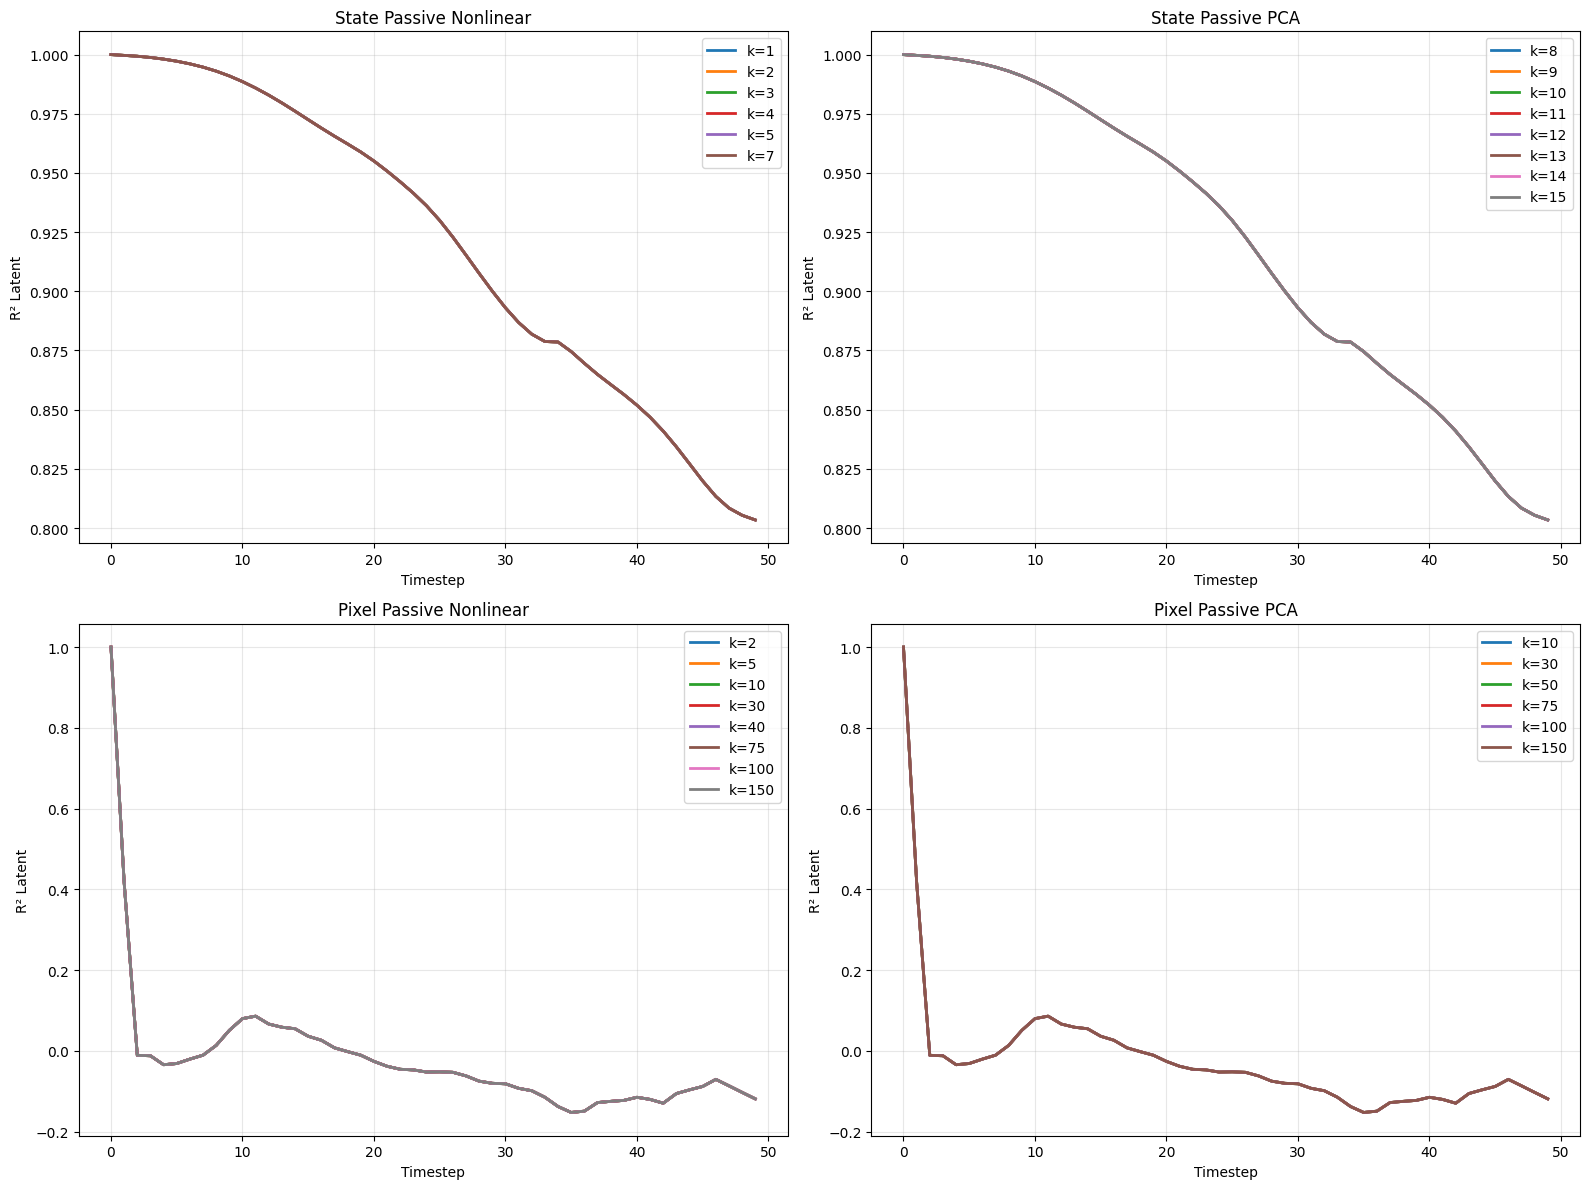

In [43]:
mean_state_passive_nonlinear = {}
for k in results_passive_nonlinear_state.keys():
    mean_state_passive_nonlinear[k], _, _ = get_bootstrap_ci(
        results_passive_nonlinear_state[k])

mean_state_passive_pca = {}
for k in results_passive_pca_state.keys():
    mean_state_passive_pca[k], _, _ = get_bootstrap_ci(
        results_passive_pca_state[k])

# pixel passive - different k values
mean_pixel_passive_nonlinear = {}
for k in results_passive_nonlinear_pixel.keys():
    mean_pixel_passive_nonlinear[k], _, _ = get_bootstrap_ci(
        results_passive_nonlinear_pixel[k])

mean_pixel_passive_pca = {}
for k in results_passive_pca_pixel.keys():
    mean_pixel_passive_pca[k], _, _ = get_bootstrap_ci(
        results_passive_pca_pixel[k])

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: State Passive Nonlinear
ax = axes[0, 0]
for k in mean_state_passive_nonlinear.keys():
    timesteps = np.arange(len(mean_state_passive_nonlinear[k]))
    ax.plot(timesteps, mean_state_passive_nonlinear[k], label=f'k={k}', lw=2)
ax.set_xlabel('Timestep')
ax.set_ylabel('R² Latent')
ax.set_title('State Passive Nonlinear')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: State Passive PCA
ax = axes[0, 1]
for k in mean_state_passive_pca.keys():
    timesteps = np.arange(len(mean_state_passive_pca[k]))
    ax.plot(timesteps, mean_state_passive_pca[k], label=f'k={k}', lw=2)
ax.set_xlabel('Timestep')
ax.set_ylabel('R² Latent')
ax.set_title('State Passive PCA')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Pixel Passive Nonlinear
ax = axes[1, 0]
for k in mean_pixel_passive_nonlinear.keys():
    timesteps = np.arange(len(mean_pixel_passive_nonlinear[k]))
    ax.plot(timesteps, mean_pixel_passive_nonlinear[k], label=f'k={k}', lw=2)
ax.set_xlabel('Timestep')
ax.set_ylabel('R² Latent')
ax.set_title('Pixel Passive Nonlinear')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Pixel Passive PCA
ax = axes[1, 1]
for k in mean_pixel_passive_pca.keys():
    timesteps = np.arange(len(mean_pixel_passive_pca[k]))
    ax.plot(timesteps, mean_pixel_passive_pca[k], label=f'k={k}', lw=2)
ax.set_xlabel('Timestep')
ax.set_ylabel('R² Latent')
ax.set_title('Pixel Passive PCA')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib as mpl

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colors: state = blue, rgb pixel = red
state_color = "#0056A6"
rgb_color = "#E85A4F"

timesteps = np.arange(len(mean_state_passive))

# ===== LEFT PLOT: PCA Projector =====
ax = axes[0]

# State - Passive
ax.plot(timesteps,
        mean_state_passive,
        color=state_color,
        lw=2.5,
        label="State (Passive)",
        linestyle='-')
ax.fill_between(timesteps,
                ci_lower_state_passive,
                ci_upper_state_passive,
                color=state_color,
                alpha=0.15)

# State - Off-policy
ax.plot(timesteps,
        mean_state_offpolicy,
        color=state_color,
        lw=2.5,
        label="State (Off-policy)",
        linestyle='--')
ax.fill_between(timesteps,
                ci_lower_state_offpolicy,
                ci_upper_state_offpolicy,
                color=state_color,
                alpha=0.08)

# RGB - Passive
ax.plot(timesteps,
        mean_rgb_passive,
        color=rgb_color,
        lw=2.5,
        label="Pixel (Passive)",
        linestyle='-')
ax.fill_between(timesteps,
                ci_lower_rgb_passive,
                ci_upper_rgb_passive,
                color=rgb_color,
                alpha=0.15)

# RGB - Off-policy
ax.plot(timesteps,
        mean_rgb_offpolicy,
        color=rgb_color,
        lw=2.5,
        label="Pixel (Off-policy)",
        linestyle='--')
ax.fill_between(timesteps,
                ci_lower_rgb_offpolicy,
                ci_upper_rgb_offpolicy,
                color=rgb_color,
                alpha=0.08)

ax.set_xlabel("Rollout length")
ax.set_ylabel("Dynamics R2")
ax.set_title("Dynamics R2 - PCA Projector")
ax.set_ylim(0, 1.05)
ax.set_xlim([timesteps[0], timesteps[-1]])
ax.grid(ls="--", alpha=0.3, zorder=0)
ax.legend(frameon=False)
ax.set_xticks(np.arange(timesteps[0], timesteps[-1] + 2, 10))
sns.despine(ax=ax)

# ===== RIGHT PLOT: Nonlinear Projector =====
ax = axes[1]

# State - Passive
ax.plot(timesteps,
        mean_state_passive_nonlinear,
        color=state_color,
        lw=2.5,
        label="State (Passive)",
        linestyle='-')
ax.fill_between(timesteps,
                ci_lower_state_passive_nonlinear,
                ci_upper_state_passive_nonlinear,
                color=state_color,
                alpha=0.15)

# State - Off-policy
ax.plot(timesteps,
        mean_state_offpolicy_nonlinear,
        color=state_color,
        lw=2.5,
        label="State (Off-policy)",
        linestyle='--')
ax.fill_between(timesteps,
                ci_lower_state_offpolicy_nonlinear,
                ci_upper_state_offpolicy_nonlinear,
                color=state_color,
                alpha=0.08)

# RGB - Passive
ax.plot(timesteps,
        mean_rgb_passive_nonlinear,
        color=rgb_color,
        lw=2.5,
        label="Pixel (Passive)",
        linestyle='-')
ax.fill_between(timesteps,
                ci_lower_rgb_passive_nonlinear,
                ci_upper_rgb_passive_nonlinear,
                color=rgb_color,
                alpha=0.15)

# RGB - Off-policy
ax.plot(timesteps,
        mean_rgb_offpolicy_nonlinear,
        color=rgb_color,
        lw=2.5,
        label="Pixel (Off-policy)",
        linestyle='--')
ax.fill_between(timesteps,
                ci_lower_rgb_offpolicy_nonlinear,
                ci_upper_rgb_offpolicy_nonlinear,
                color=rgb_color,
                alpha=0.08)

ax.set_xlabel("Rollout length")
ax.set_ylabel("Dynamics R2")
ax.set_title("Dynamics R2 - Nonlinear Projector")
ax.set_ylim(0, 1.05)
ax.set_xlim([timesteps[0], timesteps[-1]])
ax.grid(ls="--", alpha=0.3, zorder=0)
ax.legend(frameon=False)
ax.set_xticks(np.arange(timesteps[0], timesteps[-1] + 2, 10))
sns.despine(ax=ax)

plt.tight_layout()
plt.show()


NameError: name 'results_passive_state' is not defined

In [114]:
from analysis.utils import show_video_from_frames

show_video_from_frames(results_rgb_passive[0]['obs_true'][:, 6:9].transpose(
    0, 2, 3, 1),
                       save_to_file="results_rgb_passive.mp4")

Frames shape: (50, 64, 64, 3)
Video file saved at: /hkfs/home/haicore/hgf_hmgu/hgf_gib4562/tdmpc2/results_rgb_passive.mp4


'results_rgb_passive.mp4'